In [1]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
import numpy as np

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

def scatter_with_pr(x, y, **kwargs):
    pr = st.pearsonr(x, y).statistic
    ax = plt.gca()
    ax.scatter(x, y, **kwargs)
    ax.set_title(f"r={pr:.2f}")
    return ax
    
def scatter_with_pr_and_lim(x, y, **kwargs):
    ax = scatter_with_pr(x, y, **kwargs)
    if min(y) >= 0 and max(y) <= 1:
        ax.set_ylim(-0.1,1.1)

def scatter_xy(df, col1, col2, hue=None, cmap='cool'):
    plt.figure()
    ax = sns.scatterplot(data=df, x=col1, y=col2, hue=hue, palette=cmap, alpha=0.5)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title=hue)
    plt.tight_layout()
    plt.show()

In [2]:
def clean_up_column_name(c: str) -> str:
    for substr in ['kl', 'selfies']:
        c = c.replace(substr, substr.upper())
    for substr in ['euclidean', 'tanimoto', 'wasserstein']:
        c = c.replace(substr, substr.capitalize())
    if c.endswith('_10000'):
        c = c[:-len('_10000')]
    c = c.replace('_', ' ')
    c = c[0].upper() + c[1:]
    return c

MAIN_DIR = Path('../..')

study_name = "ablation_pubchem_preprocessed_with_selfies_with_properties_small_train_train_with_stratum_sample_1000000_train_a_1e-05_batch_256_epochs_5_lr_1e-4_wd_1e-5"
summary_file = MAIN_DIR/'logs'/'ablation_studies'/study_name/'summary.csv'

df = pd.read_csv(summary_file, sep=';', low_memory=False)
df = df.rename(columns = {c: clean_up_column_name(c) for c in df.columns})

df

,Properties loss coefficient,Tanimoto loss coefficient,KL div coefficient,Initialize token embeddings,Seed,Name,Reconstruction loss,KL div loss,Nb strings reconstructed,Nb tokens reconstructed,Total nb strings,Total nb tokens,String reconstruction accuracy,Token reconstruction accuracy,Reconstruction accuracy per token,Uniqueness,Validity,IntDiv1,IntDiv2,SELFIES novelty score,Mol novelty score,Fingerprint novelty score,MolWt Wasserstein,MolLogP Wasserstein,QED Wasserstein,SA Score Wasserstein,TPSA Wasserstein,BertzCT Wasserstein,Kappa1 Wasserstein,Kappa2 Wasserstein,Kappa3 Wasserstein,Pearson correlation Euclidean Tanimoto,Spearman correlation Euclidean Tanimoto,Trustworthiness 5,Trustworthiness 10,Trustworthiness 20,Trustworthiness 30,Pearson correlation Euclidean MolWt distance,Pearson correlation Euclidean MolLogP distance,Pearson correlation Euclidean TPSA distance,Pearson correlation Euclidean BertzCT distance,Pearson correlation Euclidean BalabanJ distance,Pearson correlation Euclidean Kappa1 distance,Pearson correlation Euclidean Kappa2 distance,Pearson correlation Euclidean Kappa3 distance
0,0.0,0.0,0.2,True,42,baseline_init_KL_0.2_p_0.0_T_0.0_s_42,178.511190,91.950990,330,14116950,200000,19216384,0.001650,0.734631,"{'[C]': 0.5408997955010225, '[=Branch1]': 0.21...",0.9961,0.9999,0.887655,0.881974,1.000000,0.999799,0.999699,29.383990,0.616230,0.066588,1.814576,14.305792,137.139853,1.570804,1.481199,1.271447,-0.385625,-0.368443,0.812756,0.791399,0.769066,0.756931,0.257833,0.234977,0.184143,0.208068,0.190893,0.283222,0.265614,0.083299
1,0.0,0.0,0.2,False,42,baseline_noinit_KL_0.2_p_0.0_T_0.0_s_42,177.451800,106.101466,1236,14271571,200000,19272128,0.006180,0.740529,"{'[C]': 0.5214723926380368, '[=Branch1]': 0.19...",0.9952,0.9986,0.887828,0.882243,1.000000,0.999899,0.999799,31.687417,0.274764,0.112186,1.884838,5.462254,136.910651,1.822693,1.956333,1.724893,-0.391597,-0.374567,0.818651,0.796957,0.776673,0.764753,0.267506,0.219803,0.192168,0.230437,0.218699,0.284345,0.249108,0.088903
2,0.0,0.2,0.2,True,42,baseline_init_KL_0.2_p_0.0_T_0.2_s_42,171.498227,109.871582,578,14270222,200000,19247552,0.002890,0.741405,"{'[C]': 0.5398773006134969, '[=Branch1]': 0.20...",0.9965,1.0000,0.880974,0.875643,1.000000,0.999799,0.999498,32.205890,0.570593,0.053794,1.785804,15.172098,173.759858,1.670490,1.595477,1.363991,-0.666524,-0.660290,0.879895,0.866932,0.854531,0.846301,0.237647,0.263252,0.204731,0.272605,0.314652,0.235193,0.246632,0.113883
3,0.0,0.4,0.2,True,42,baseline_init_KL_0.2_p_0.0_T_0.4_s_42,175.915279,126.709146,637,14371680,200000,19394240,0.003185,0.741028,"{'[C]': 0.5460122699386503, '[=Branch1]': 0.26...",0.9972,1.0000,0.880181,0.875020,1.000000,1.000000,1.000000,31.451236,0.503333,0.056014,1.827708,14.294343,176.072000,1.664756,1.585516,1.349494,-0.726996,-0.722823,0.912687,0.902756,0.890507,0.883572,0.206405,0.238547,0.191180,0.250672,0.325612,0.203078,0.227391,0.108981
4,0.0,0.6,0.2,True,42,baseline_init_KL_0.2_p_0.0_T_0.6_s_42,195.347347,139.022654,882,14079871,200000,19151808,0.004410,0.735172,"{'[C]': 0.523517382413088, '[=Branch1]': 0.203...",0.9966,0.9995,0.882953,0.877710,1.000000,1.000000,1.000000,32.870985,0.278763,0.047850,1.836502,12.419952,194.250353,1.470848,1.061401,1.060241,-0.752822,-0.749660,0.926913,0.916478,0.905789,0.899444,0.187562,0.217374,0.183385,0.231257,0.319824,0.182471,0.207478,0.108119
5,0.0,0.8,0.2,True,42,baseline_init_KL_0.2_p_0.0_T_0.8_s_42,190.564140,151.930247,898,14268105,200000,19345088,0.004490,0.737557,"{'[C]': 0.5224948875255624, '[=Branch1]': 0.21...",0.9955,0.9998,0.884827,0.879402,1.000000,0.999799,0.999699,31.333155,0.301893,0.060495,1.798361,12.481475,180.741476,1.481790,1.261476,1.254722,-0.772674,-0.769709,0.936386,0.927501,0.917948,0.911881,0.173573,0.202018,0.170212,0.218262,0.315266,0.167158,0.197089,0.100613
6,0.0,1.0,0.2,True,42,baseline_init_KL_0.2_p_0.0_T_1.0_s_42,183.928313,164.597249,1159,14354997,200000,19265280,0.005795,0.745123,"{'[C]': 0.5388548057259713, '[=Bra

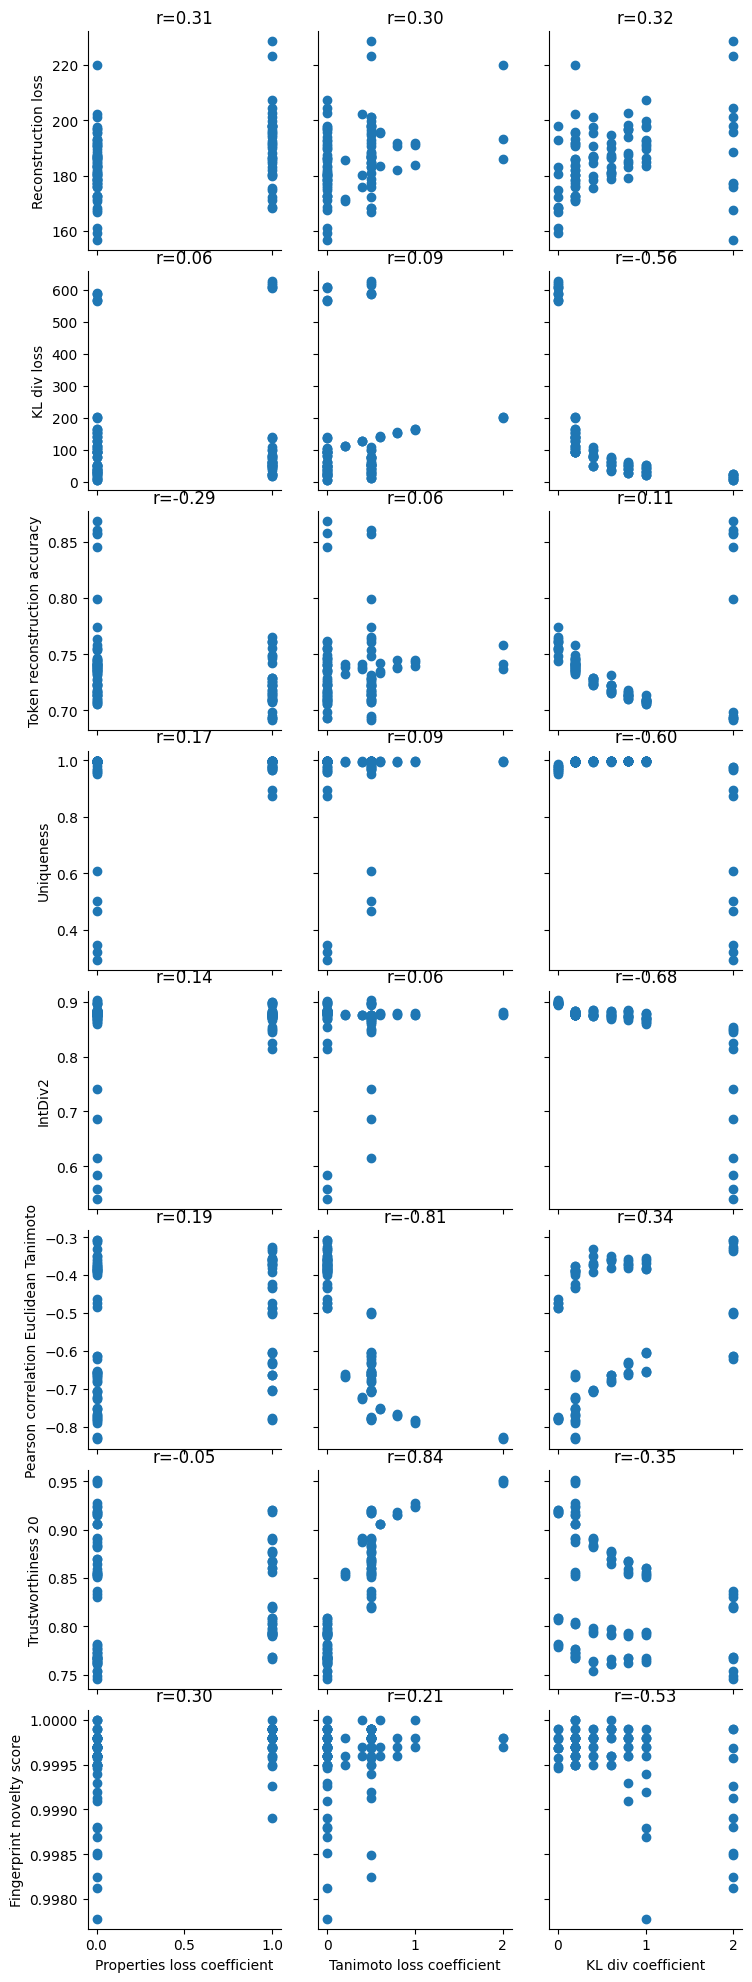

In [3]:
g = sns.PairGrid(df, x_vars=['Properties loss coefficient', 'Tanimoto loss coefficient', 'KL div coefficient'],
                 y_vars=['Reconstruction loss', 'KL div loss', 'Token reconstruction accuracy',
                   'Uniqueness', 'IntDiv2', 'Pearson correlation Euclidean Tanimoto',
                   'Trustworthiness 20', 'Fingerprint novelty score'])
g.map(scatter_with_pr)

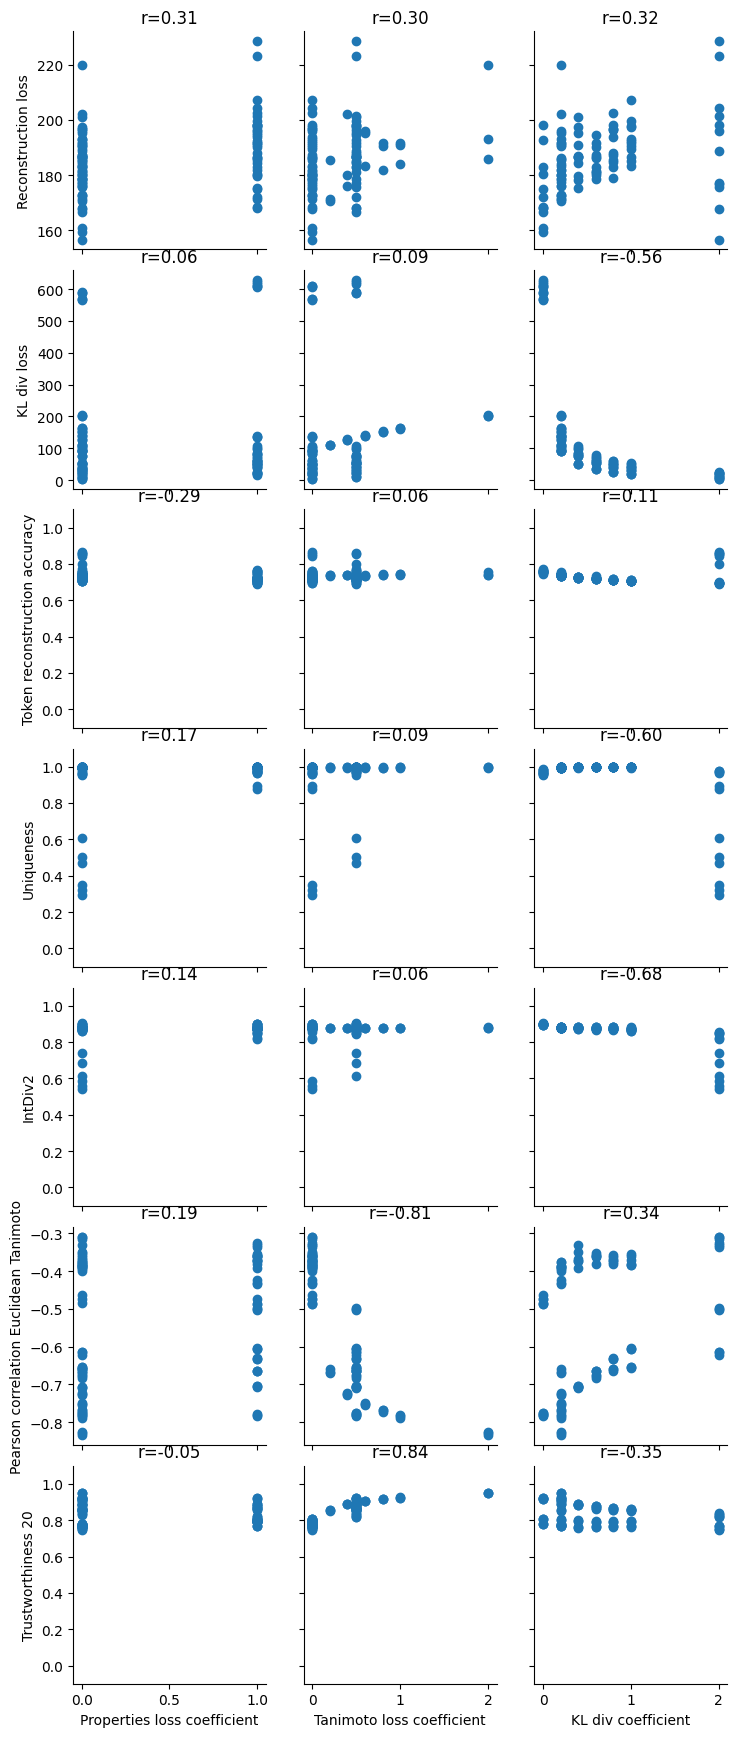

In [4]:
g = sns.PairGrid(df, x_vars=['Properties loss coefficient', 'Tanimoto loss coefficient', 'KL div coefficient'],
                 y_vars=['Reconstruction loss', 'KL div loss', 'Token reconstruction accuracy',
                   'Uniqueness', 'IntDiv2', 'Pearson correlation Euclidean Tanimoto',
                   'Trustworthiness 20'])
g.map(scatter_with_pr_and_lim)

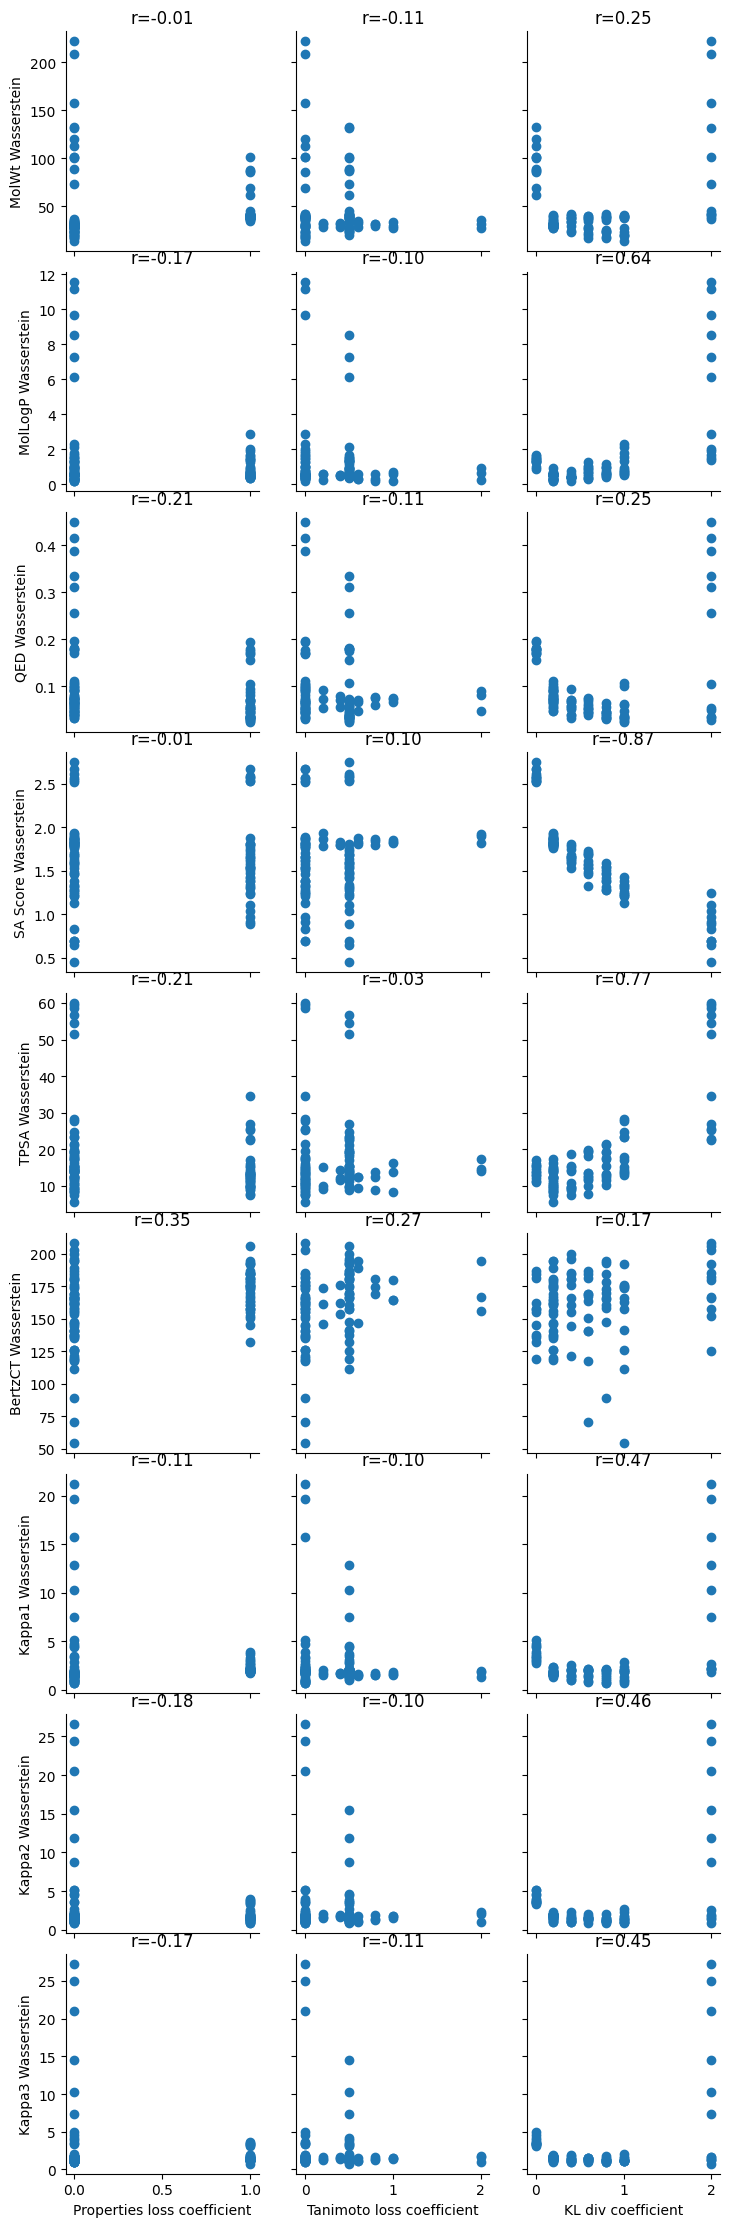

In [5]:
g = sns.PairGrid(df, x_vars=['Properties loss coefficient', 'Tanimoto loss coefficient', 'KL div coefficient'],
                 y_vars=list([c for c in df.columns if c.endswith('Wasserstein')]))
g.map(scatter_with_pr)

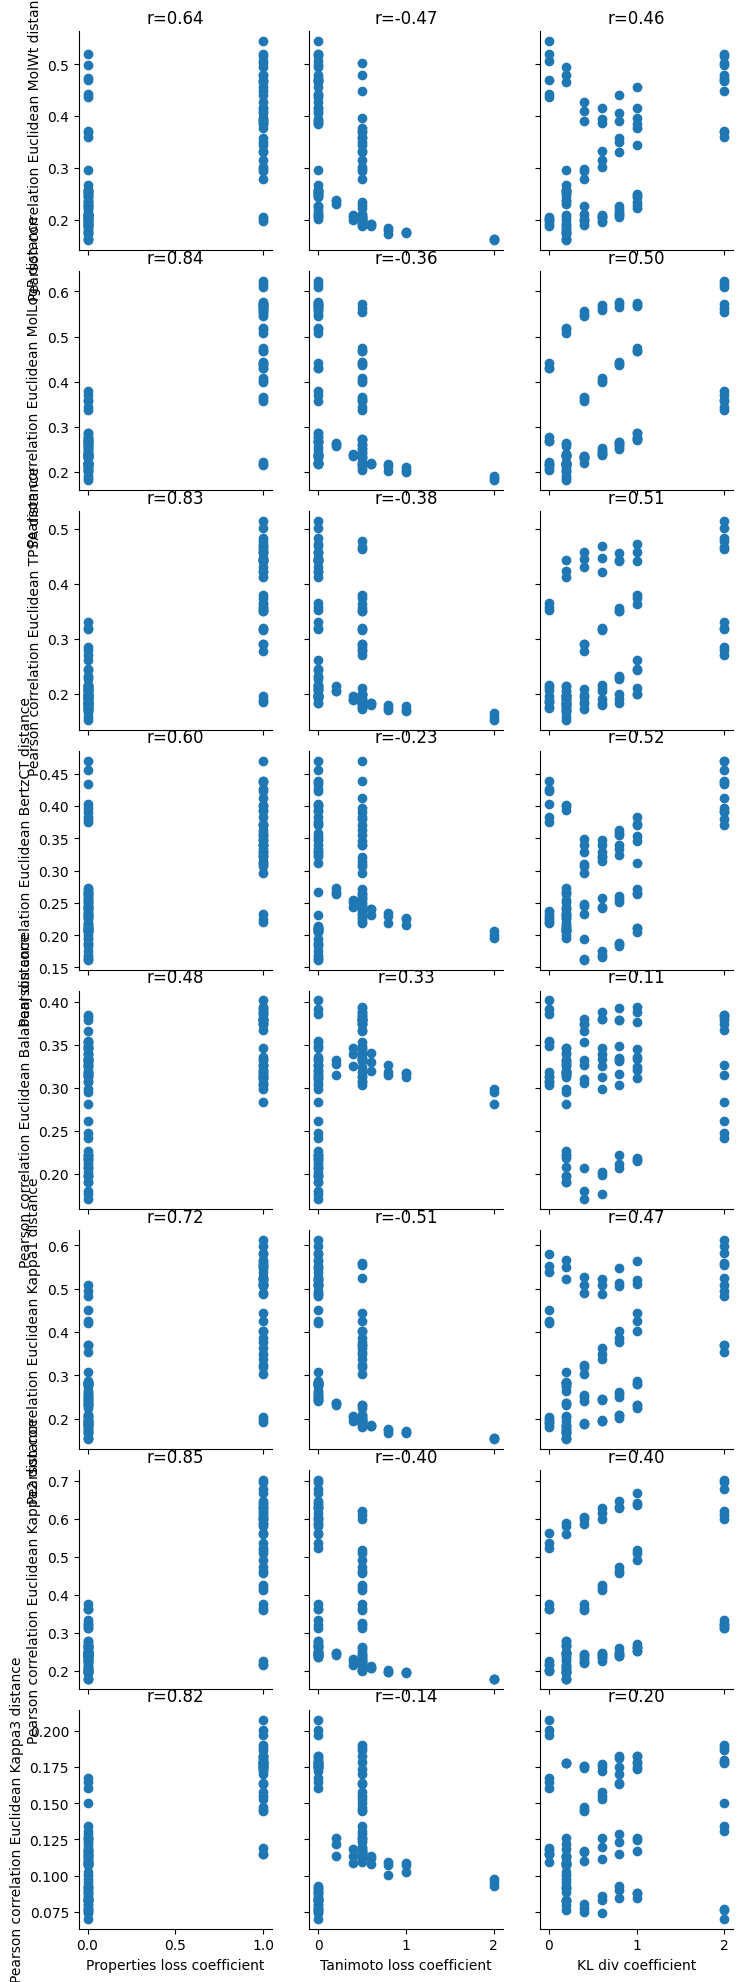

In [6]:
g = sns.PairGrid(df, x_vars=['Properties loss coefficient', 'Tanimoto loss coefficient', 'KL div coefficient'],
                 y_vars=list([c for c in df.columns if c.startswith('Pearson') and c.endswith('distance')]))
g.map(scatter_with_pr)

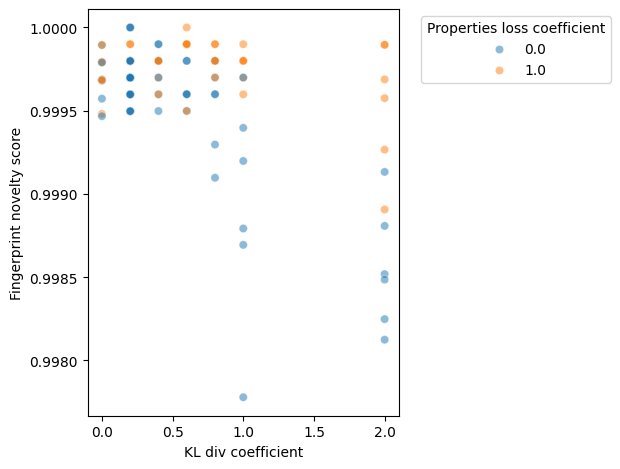

In [7]:
scatter_xy(df, 'KL div coefficient', 'Fingerprint novelty score', hue='Properties loss coefficient', cmap='tab10')

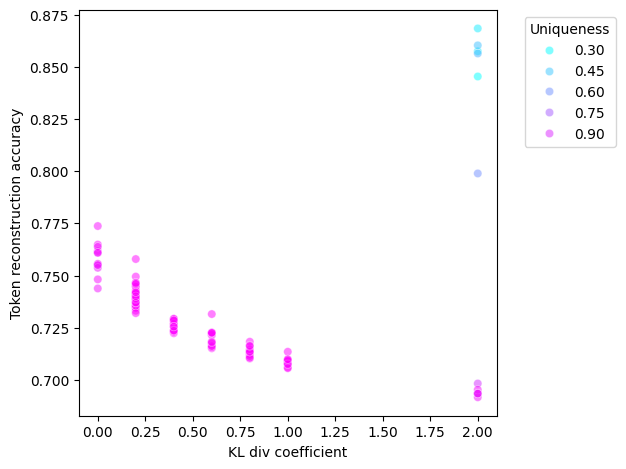

In [8]:
scatter_xy(df, 'KL div coefficient', 'Token reconstruction accuracy', hue='Uniqueness')

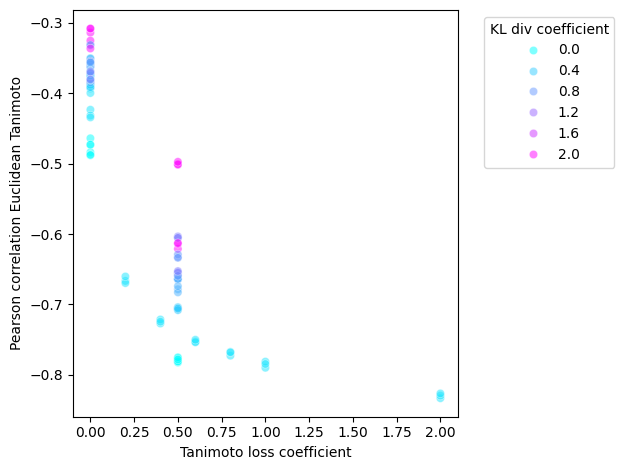

In [9]:
scatter_xy(df,'Tanimoto loss coefficient', 'Pearson correlation Euclidean Tanimoto',  hue='KL div coefficient')

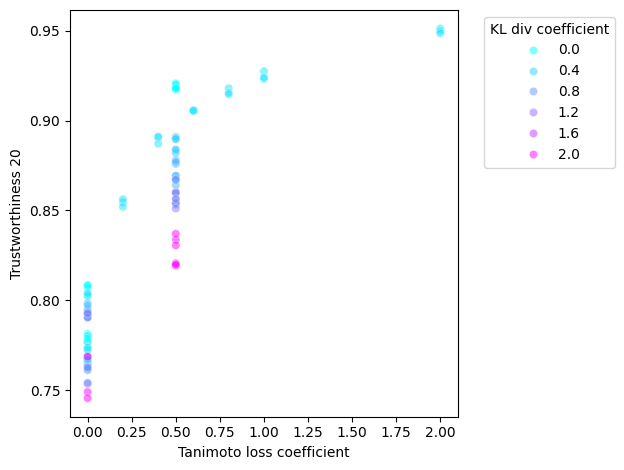

In [10]:
scatter_xy(df,'Tanimoto loss coefficient', 'Trustworthiness 20',  hue='KL div coefficient')

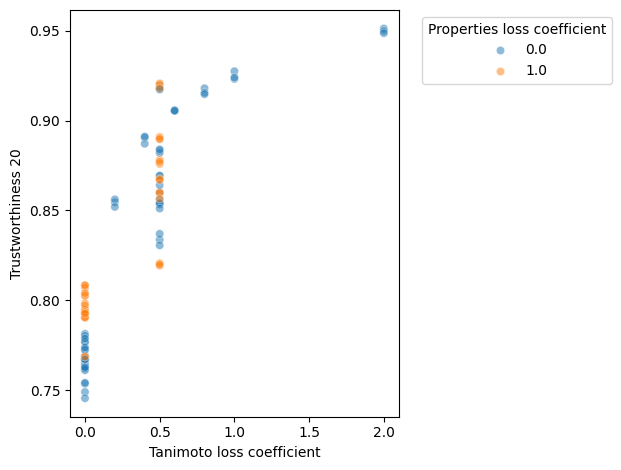

In [11]:
scatter_xy(df,'Tanimoto loss coefficient', 'Trustworthiness 20',  hue='Properties loss coefficient', cmap='tab10')

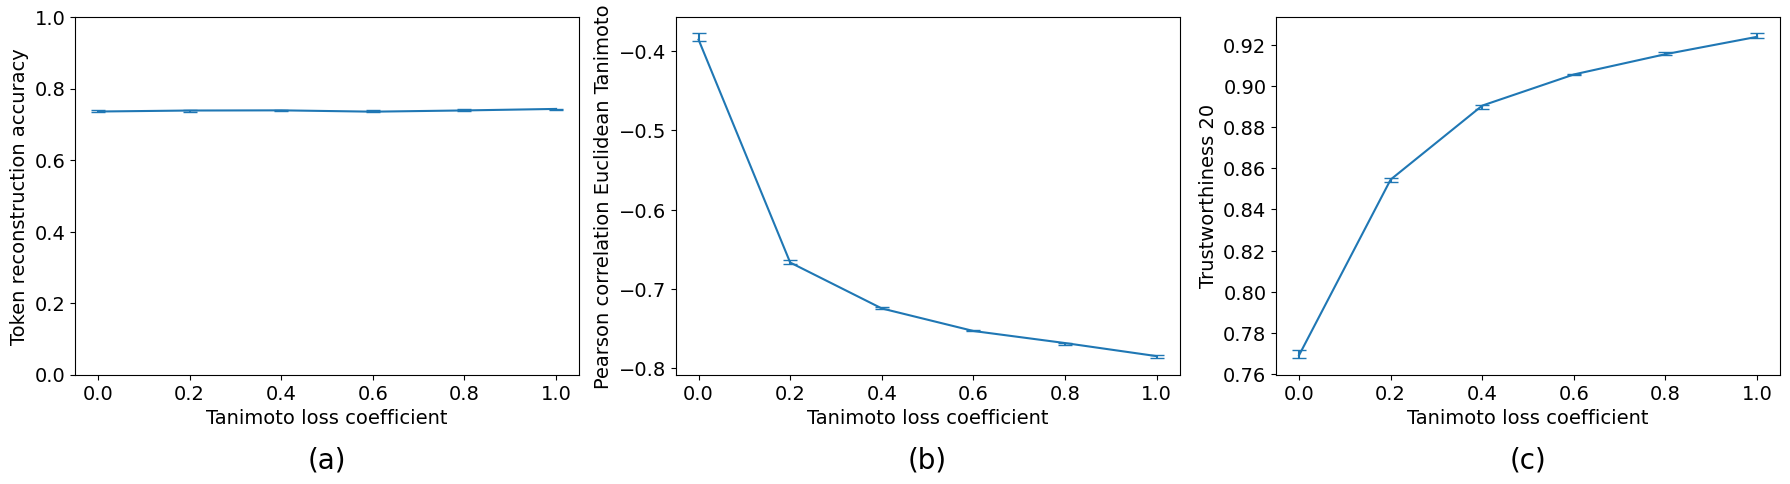

In [12]:
def plot_with_errorbar(df, x, y, ymin=None, ymax=None, fontsize=14, ax=None):
    stats = df.groupby(x)[y].describe()
    ax.errorbar(
        stats.index,
        stats["50%"],
        yerr=[stats["50%"]-stats["25%"], stats["75%"]-stats["50%"]],
        capsize=5
    )
    ax.set_xlabel(x, fontsize=fontsize)
    ax.set_ylabel(y, fontsize=fontsize)
    ax.set_ylim((ymin, ymax))
    ax.tick_params(axis='both', labelsize=fontsize)

df_no_props = df[(df['KL div coefficient']==0.2) & (df['Properties loss coefficient']==0.0) & (df['Initialize token embeddings'])]
df_no_props = df_no_props[df_no_props['Tanimoto loss coefficient'] < 2]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_with_errorbar(df_no_props, 'Tanimoto loss coefficient', 'Token reconstruction accuracy', ymin=0, ymax=1, ax=axes[0])
plot_with_errorbar(df_no_props, 'Tanimoto loss coefficient', 'Pearson correlation Euclidean Tanimoto', ax=axes[1])
plot_with_errorbar(df_no_props, 'Tanimoto loss coefficient', 'Trustworthiness 20', ax=axes[2])


labels = ['(a)', '(b)', '(c)']
for ax, label in zip(axes, labels):
    ax.text(0.5, -0.2, label, transform=ax.transAxes,
            ha='center', va='top', fontsize=20)

plt.tight_layout()
plt.show()


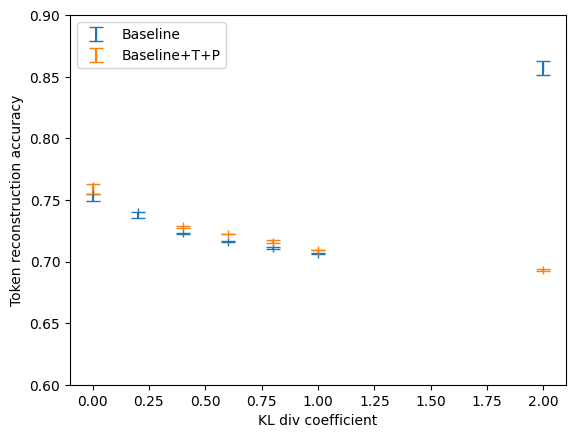

In [13]:
def plot_with_errorbar_multiple(df, x, y, ymin=None, ymax=None, label=None):
    stats = df.groupby(x)[y].describe()
    plt.errorbar(
        stats.index,
        stats["50%"],
        yerr=[stats["50%"]-stats["25%"], stats["75%"]-stats["50%"]], capsize=5, fmt='|',
        label=label
    )
    plt.xlabel(x)
    plt.ylabel(y)
    plt.ylim((ymin,ymax))

plt.figure()
plot_with_errorbar_multiple(df[(df['Tanimoto loss coefficient']==0.0) & (df['Properties loss coefficient']==0.0)], 'KL div coefficient', 'Token reconstruction accuracy', ymin=0.6, ymax=0.9, label='Baseline')
plot_with_errorbar_multiple(df[(df['Tanimoto loss coefficient']==0.5) & (df['Properties loss coefficient']==1.0)], 'KL div coefficient', 'Token reconstruction accuracy', ymin=0.6, ymax=0.9, label='Baseline+T+P')
plt.legend()
plt.show()

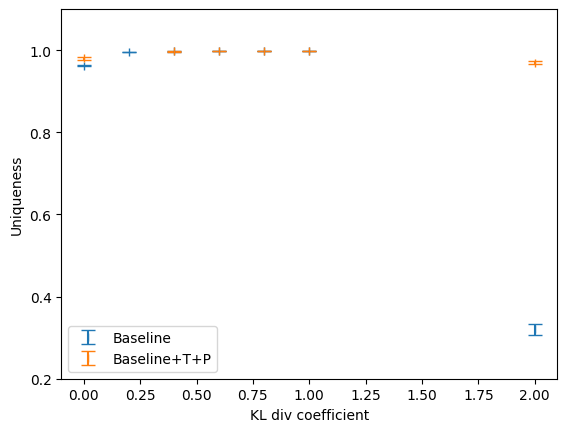

In [14]:
plt.figure()
plot_with_errorbar_multiple(df[(df['Tanimoto loss coefficient']==0.0) & (df['Properties loss coefficient']==0.0)], 'KL div coefficient', 'Uniqueness', ymin=0.2, ymax=1.1, label='Baseline')
plot_with_errorbar_multiple(df[(df['Tanimoto loss coefficient']==0.5) & (df['Properties loss coefficient']==1.0)], 'KL div coefficient', 'Uniqueness', ymin=0.2, ymax=1.1, label='Baseline+T+P')
plt.legend()
plt.show()

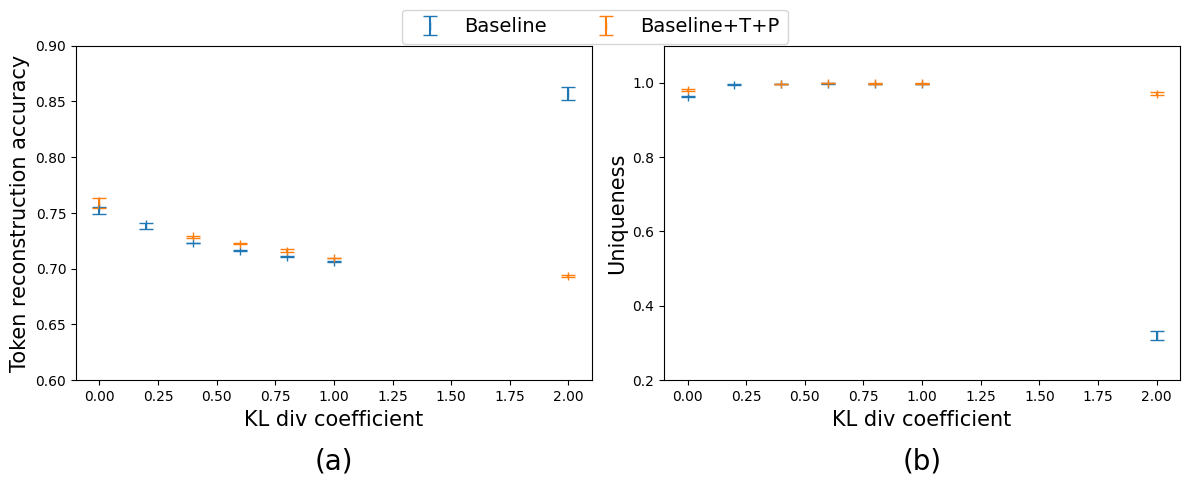

In [15]:
def plot_with_errorbar_multiple(df, x, y, ymin=None, ymax=None, label=None, ax=None, fontsize=15):
    stats = df.groupby(x)[y].describe()
    ax.errorbar(
        stats.index,
        stats["50%"],
        yerr=[stats["50%"]-stats["25%"], stats["75%"]-stats["50%"]],
        capsize=5, fmt='|',
        label=label
    )
    ax.set_xlabel(x, fontsize=fontsize)
    ax.set_ylabel(y, fontsize=fontsize)
    ax.set_ylim((ymin, ymax))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_with_errorbar_multiple(
    df[(df['Tanimoto loss coefficient']==0.0) & (df['Properties loss coefficient']==0.0)],
    'KL div coefficient', 'Token reconstruction accuracy', ymin=0.6, ymax=0.9,
    label='Baseline', ax=axes[0]
)
plot_with_errorbar_multiple(
    df[(df['Tanimoto loss coefficient']==0.5) & (df['Properties loss coefficient']==1.0)],
    'KL div coefficient', 'Token reconstruction accuracy', ymin=0.6, ymax=0.9,
    label='Baseline+T+P', ax=axes[0]
)

plot_with_errorbar_multiple(
    df[(df['Tanimoto loss coefficient']==0.0) & (df['Properties loss coefficient']==0.0)],
    'KL div coefficient', 'Uniqueness', ymin=0.2, ymax=1.1,
    label='Baseline', ax=axes[1]
)
plot_with_errorbar_multiple(
    df[(df['Tanimoto loss coefficient']==0.5) & (df['Properties loss coefficient']==1.0)],
    'KL div coefficient', 'Uniqueness', ymin=0.2, ymax=1.1,
    label='Baseline+T+P', ax=axes[1]
)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, fontsize=14)

panels = ['(a)', '(b)']
for ax, panel in zip(axes, panels):
    ax.text(0.5, -0.2, panel, transform=ax.transAxes,
            ha='center', va='top', fontsize=20)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

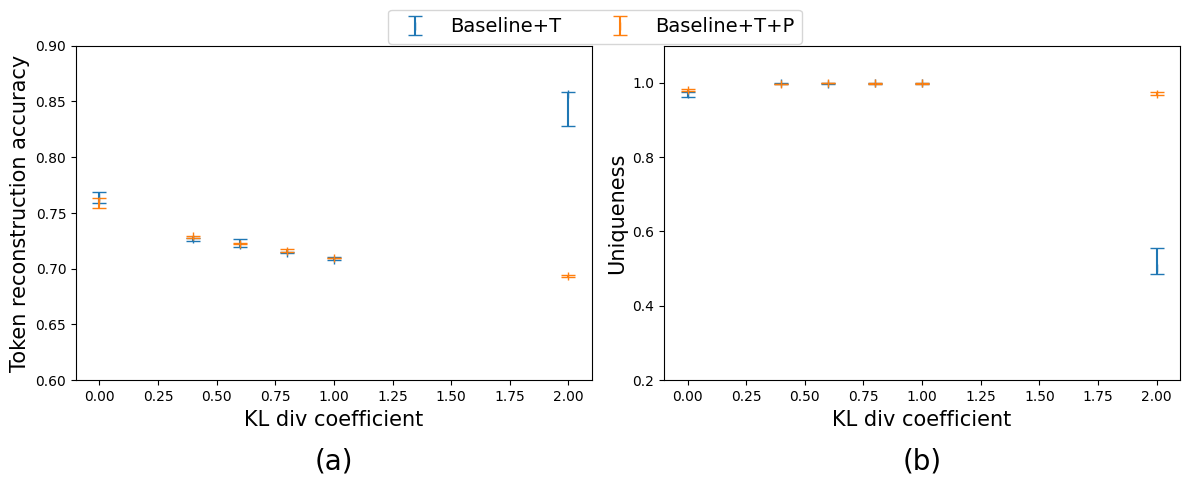

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_with_errorbar_multiple(
    df[(df['Tanimoto loss coefficient']==0.5) & (df['Properties loss coefficient']==0.0)],
    'KL div coefficient', 'Token reconstruction accuracy', ymin=0.6, ymax=0.9,
    label='Baseline+T', ax=axes[0]
)
plot_with_errorbar_multiple(
    df[(df['Tanimoto loss coefficient']==0.5) & (df['Properties loss coefficient']==1.0)],
    'KL div coefficient', 'Token reconstruction accuracy', ymin=0.6, ymax=0.9,
    label='Baseline+T+P', ax=axes[0]
)

plot_with_errorbar_multiple(
    df[(df['Tanimoto loss coefficient']==0.5) & (df['Properties loss coefficient']==0.0)],
    'KL div coefficient', 'Uniqueness', ymin=0.2, ymax=1.1,
    label='Baseline+T', ax=axes[1]
)
plot_with_errorbar_multiple(
    df[(df['Tanimoto loss coefficient']==0.5) & (df['Properties loss coefficient']==1.0)],
    'KL div coefficient', 'Uniqueness', ymin=0.2, ymax=1.1,
    label='Baseline+T+P', ax=axes[1]
)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, fontsize=14)

panels = ['(a)', '(b)']
for ax, panel in zip(axes, panels):
    ax.text(0.5, -0.2, panel, transform=ax.transAxes,
            ha='center', va='top', fontsize=20)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

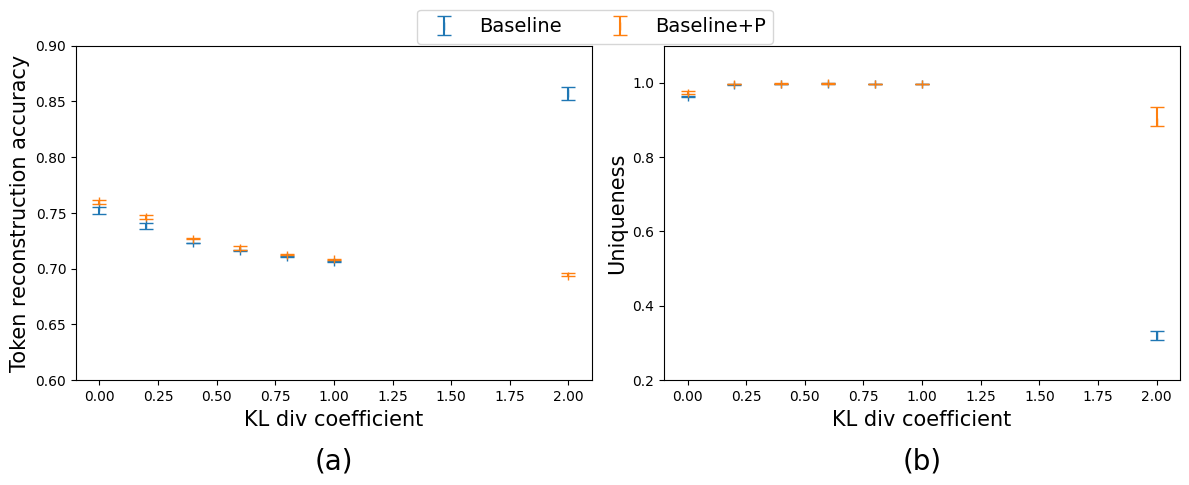

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_with_errorbar_multiple(
    df[(df['Tanimoto loss coefficient']==0.0) & (df['Properties loss coefficient']==0.0)],
    'KL div coefficient', 'Token reconstruction accuracy', ymin=0.6, ymax=0.9,
    label='Baseline', ax=axes[0]
)
plot_with_errorbar_multiple(
    df[(df['Tanimoto loss coefficient']==0.0) & (df['Properties loss coefficient']==1.0)],
    'KL div coefficient', 'Token reconstruction accuracy', ymin=0.6, ymax=0.9,
    label='Baseline+P', ax=axes[0]
)

plot_with_errorbar_multiple(
    df[(df['Tanimoto loss coefficient']==0.0) & (df['Properties loss coefficient']==0.0)],
    'KL div coefficient', 'Uniqueness', ymin=0.2, ymax=1.1,
    label='Baseline', ax=axes[1]
)
plot_with_errorbar_multiple(
    df[(df['Tanimoto loss coefficient']==0.0) & (df['Properties loss coefficient']==1.0)],
    'KL div coefficient', 'Uniqueness', ymin=0.2, ymax=1.1,
    label='Baseline+P', ax=axes[1]
)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, fontsize=14)

panels = ['(a)', '(b)']
for ax, panel in zip(axes, panels):
    ax.text(0.5, -0.2, panel, transform=ax.transAxes,
            ha='center', va='top', fontsize=20)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

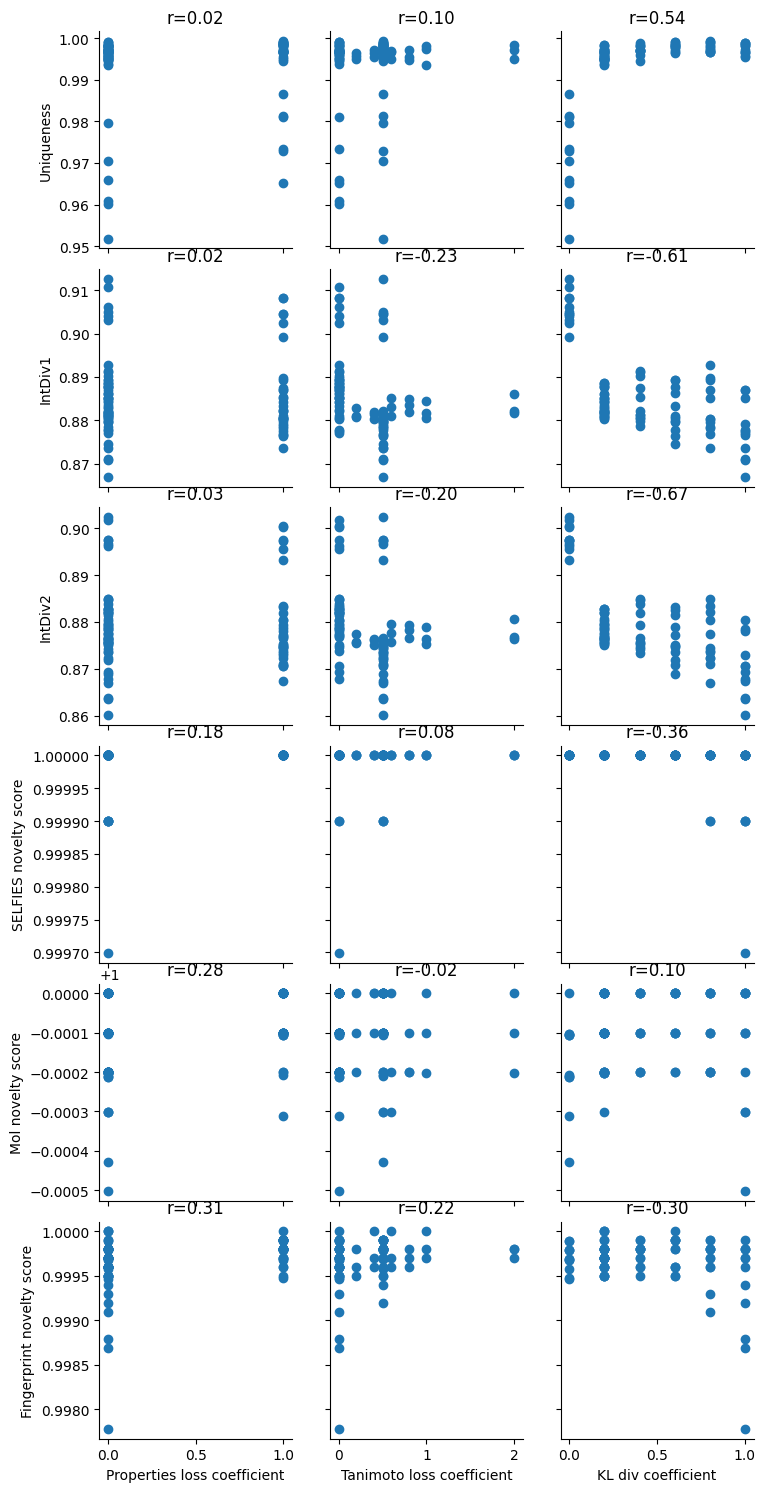

In [18]:
df_no_collapse = df[df['KL div coefficient']<2.0]
g = sns.PairGrid(df_no_collapse, x_vars=['Properties loss coefficient', 'Tanimoto loss coefficient', 'KL div coefficient'],
                 y_vars=['Uniqueness', 'IntDiv1', 'IntDiv2', 'SELFIES novelty score', 'Mol novelty score', 'Fingerprint novelty score'])
g.map(scatter_with_pr)

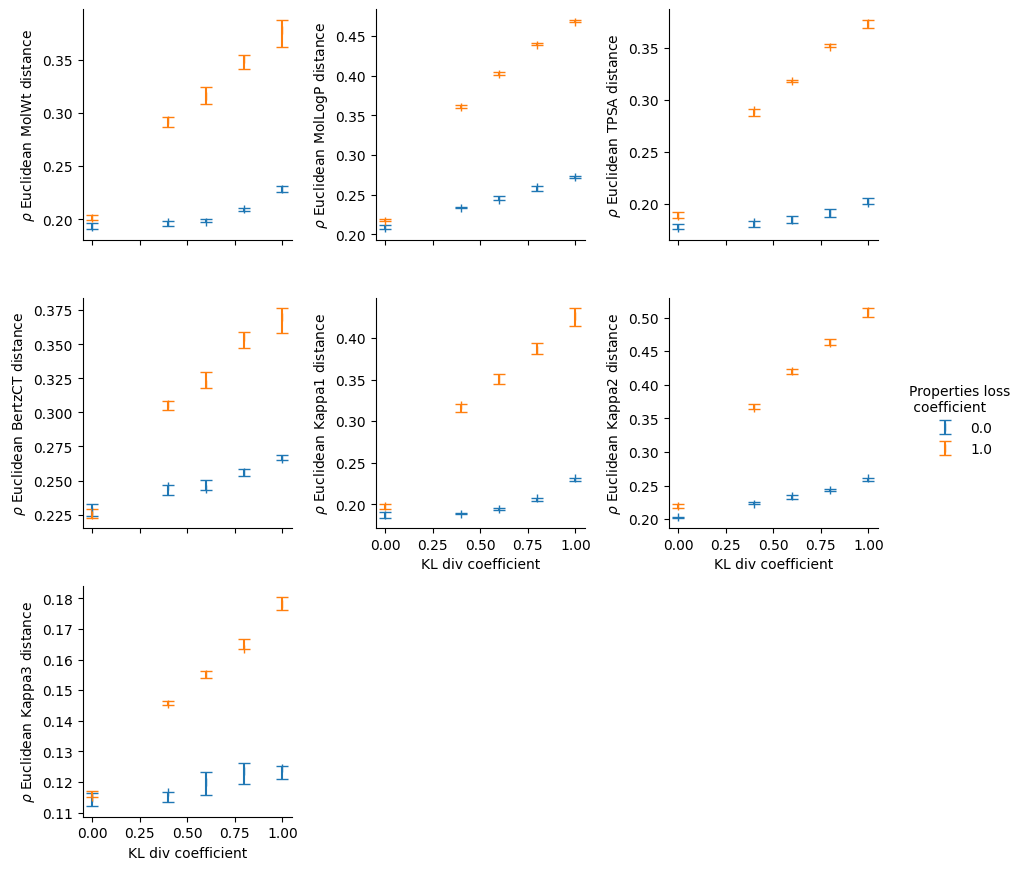

In [19]:
def errorbar_iqr(x, y, color=None, label=None, **kws):
    ax = plt.gca()
    d = pd.DataFrame({"x": np.asarray(x), "y": np.asarray(y)})
    stats = d.groupby("x")["y"].describe()  # has 25%, 50%, 75%
    stats = stats.sort_index()
    ax.errorbar(
        stats.index,
        stats["50%"],
        yerr=[stats["50%"]-stats["25%"], stats["75%"]-stats["50%"]],
        fmt="|", capsize=4, color=color, label=label
    )

properties_regressed = ['MolWt', 'MolLogP', 'TPSA', 'BertzCT', 'Kappa1', 'Kappa2', 'Kappa3']
columns = [f'Pearson correlation Euclidean {p} distance' for p in properties_regressed]
df_no_collapse_tanimoto_standard = df[(df['KL div coefficient']<2.0) & (df['Tanimoto loss coefficient']==0.5)]

df_long = df_no_collapse_tanimoto_standard.melt(
    id_vars=["KL div coefficient", "Properties loss coefficient"],
    value_vars=columns,
    var_name="variable",
    value_name="value"
)

g = sns.FacetGrid(
    df_long,
    col="variable", col_wrap=3,
    hue="Properties loss coefficient",
    sharex=True, sharey=False
)
g.map(errorbar_iqr, "KL div coefficient", "value")
g.add_legend(title="Properties loss \n coefficient")
g.legend.set_bbox_to_anchor((1.01, 0.5))
for ax, title in zip(g.axes.flat, g.col_names):
    title = title.replace('Pearson correlation', r'$\rho$')
    ax.set_ylabel(title)
    ax.set_title("")
g.fig.subplots_adjust(wspace=0.4)